# Hypothesis Testing

**Module 4: Statistical Testing** | Lean Six Sigma Data Analytics

---

## From Estimation to Testing

So far, we have focused on **estimation**:
- Describe a population using sample data
- Estimate parameters (mean, std dev, etc.)
- Estimation is merely **descriptive**

Now we switch to **testing**:
- Make a **claim** (hypothesis)
- Use **data** to test this claim
- Arrive at a **decision**

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

print('Ready for hypothesis testing!')


Ready for hypothesis testing!


---

## Example: The Pregnancy Duration Problem

Meet **Mary** and **Peter**:
- Mary gives birth to a child
- Peter works for the navy and hasn't seen Mary for more than **10 months** (305 days)
- The average pregnancy duration is **40 weeks** (280 days)

**The question:** Would you be worried if you were Peter?

**The hypothesis:** The child is Peter's.

To test this, we need **data** on pregnancy durations.

---

## The Evidence (Data)

**Data from Kieler et al.** on pregnancy duration:
- Approximately **normally distributed**
- Mean (μ) = **282.5 days**
- Standard deviation (σ) = **10.5 days**

If the child is Peter's, Mary must have been pregnant for at least **305 days**.

In [2]:
# Pregnancy duration data from Kieler et al.
mu = 282.5      # Mean pregnancy duration (days)
sigma = 10.5    # Standard deviation (days)

# Mary's situation
peter_absent = 305  # Days since Peter last saw Mary

print('Pregnancy Duration Data (Kieler et al.)')
print(f'  Mean: {mu} days')
print(f'  Std Dev: {sigma} days')
print()
print(f'Mary must have been pregnant for at least {peter_absent} days.')

Pregnancy Duration Data (Kieler et al.)
  Mean: 282.5 days
  Std Dev: 10.5 days

Mary must have been pregnant for at least 305 days.


---

## Easy Cases vs. Gray Area

| Pregnancy Duration | Suspicion Level | Why? |
|-------------------|-----------------|------|
| 285 days | Not suspicious | Very close to average (282.5) |
| 400 days | Very suspicious | Improbably long (elephant territory!) |
| **305 days** | **Gray area** | Could go either way |

For the gray area, we need **more evidence** - specifically, we need to consider the **variation** in pregnancy durations.

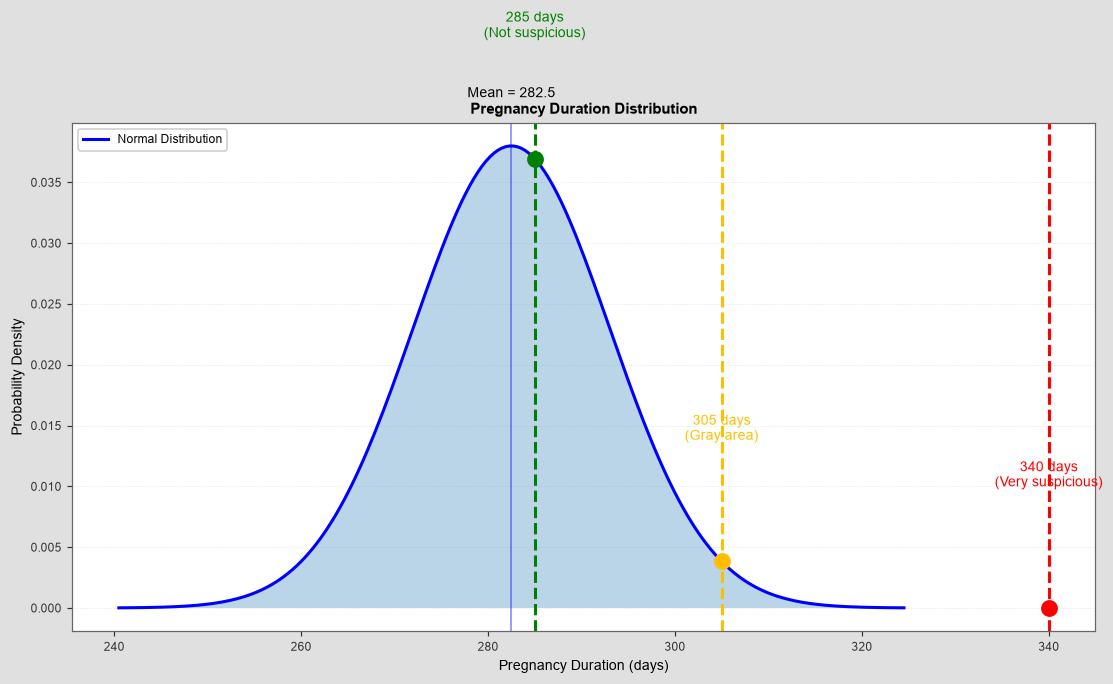

In [3]:
# Visualize the distribution and the three cases
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
y = stats.norm.pdf(x, mu, sigma)

ax.plot(x, y, 'b-', lw=2, label='Normal Distribution')
ax.fill_between(x, y, alpha=0.3)

# Mark the three cases
cases = [
    (285, 'green', '285 days\n(Not suspicious)'),
    (305, ms.GOLD, '305 days\n(Gray area)'),
    (340, 'red', '340 days\n(Very suspicious)')
]

for val, color, label in cases:
    ax.axvline(x=val, color=color, linestyle='--', lw=2)
    ax.plot(val, stats.norm.pdf(val, mu, sigma), 'o', color=color, markersize=10)
    ax.annotate(label, xy=(val, stats.norm.pdf(val, mu, sigma)), 
                xytext=(val, stats.norm.pdf(val, mu, sigma) + 0.01),
                ha='center', fontsize=9, color=color)

ax.axvline(x=mu, color='blue', linestyle='-', lw=1, alpha=0.5)
ax.text(mu, 0.042, f'Mean = {mu}', ha='center', fontsize=9)

ax.set_xlabel('Pregnancy Duration (days)')
ax.set_ylabel('Probability Density')
ax.set_title('Pregnancy Duration Distribution')
ax.legend()
plt.show()

---

## The P-Value

The **p-value** is:
- A **probability** (that's why it's called p-value)
- The probability of observing a result **at least as extreme** as what we observed
- In this example: the probability that a pregnancy takes **at least 305 days**

In [4]:
# Calculate the p-value
# P(X >= 305) = 1 - P(X < 305) = 1 - CDF(305)

p_value = 1 - stats.norm.cdf(peter_absent, mu, sigma)

print('P-VALUE CALCULATION')
print('=' * 50)
print(f'Question: What is P(pregnancy >= {peter_absent} days)?')
print()
print(f'p-value = {p_value:.4f} = {p_value*100:.2f}%')
print()
print(f'Interpretation: Only {p_value*100:.1f}% of all pregnancies take this long.')
print(f'Mary\'s pregnancy duration of {peter_absent} days is SUSPICIOUS.')

P-VALUE CALCULATION
Question: What is P(pregnancy >= 305 days)?

p-value = 0.0161 = 1.61%

Interpretation: Only 1.6% of all pregnancies take this long.
Mary's pregnancy duration of 305 days is SUSPICIOUS.


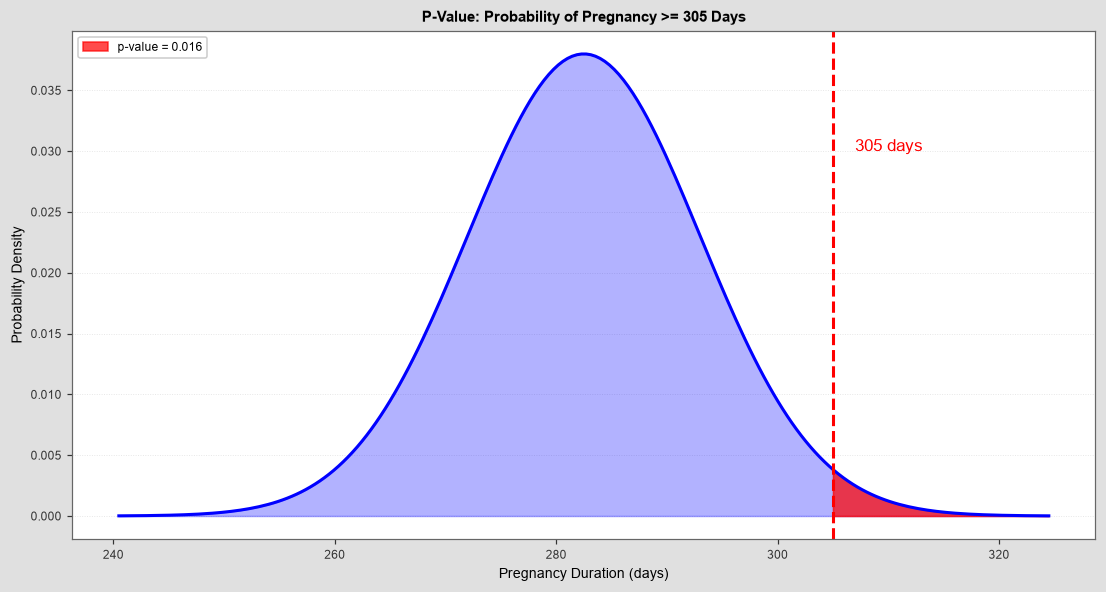

The red shaded area represents the p-value: 0.016 (1.6%)


In [5]:
# Visualize the p-value
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
y = stats.norm.pdf(x, mu, sigma)

ax.plot(x, y, 'b-', lw=2)
ax.fill_between(x, y, alpha=0.3, color='blue')

# Shade the p-value region
x_pval = np.linspace(peter_absent, mu + 4*sigma, 100)
y_pval = stats.norm.pdf(x_pval, mu, sigma)
ax.fill_between(x_pval, y_pval, alpha=0.7, color='red', label=f'p-value = {p_value:.3f}')

ax.axvline(x=peter_absent, color='red', linestyle='--', lw=2)
ax.text(peter_absent + 2, 0.03, f'{peter_absent} days', fontsize=11, color='red')

ax.set_xlabel('Pregnancy Duration (days)')
ax.set_ylabel('Probability Density')
ax.set_title(f'P-Value: Probability of Pregnancy >= {peter_absent} Days')
ax.legend(loc='upper left')
plt.show()

print(f'The red shaded area represents the p-value: {p_value:.3f} ({p_value*100:.1f}%)')

---

## What is Hypothesis Testing?

Hypothesis testing is:
- A procedure to **arrive at a decision**
- Done as **objectively** as possible
- Deals with **uncertainty** in a rational manner
- Can quantify the **risk of a false decision**

---

## The Hypothesis Testing Process

```
┌─────────────────────────────────────────────────────────────────┐
│  1. STATE YOUR HYPOTHESES                                       │
│     ┌──────────────────────┐    ┌──────────────────────┐        │
│     │  H₀ (Null Hypothesis)│    │  H₁ (Alternative)    │        │
│     │  "No effect"         │    │  "There IS an effect"│        │
│     └──────────────────────┘    └──────────────────────┘        │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  2. COLLECT EVIDENCE (DATA)                                     │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  3. CALCULATE P-VALUE                                           │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  4. MAKE A DECISION                                             │
│                                                                 │
│     p-value < 0.05  →  REJECT H₀ (significant effect)          │
│     p-value >= 0.05 →  DO NOT REJECT H₀ (no proof of effect)   │
└─────────────────────────────────────────────────────────────────┘
```

---

## The 0.05 Threshold

| p-value | Decision | Interpretation |
|---------|----------|----------------|
| **< 0.05** | Reject H₀ | Significant effect found |
| **>= 0.05** | Do not reject H₀ | No proof of effect |

**0.05 (5%)** is a commonly used threshold (also called significance level or α).

In [6]:
# Decision for Mary and Peter
alpha = 0.05

print('DECISION FOR MARY AND PETER')
print('=' * 50)
print(f'p-value = {p_value:.4f}')
print(f'Threshold (α) = {alpha}')
print()

if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < α ({alpha})')
    print()
    print('DECISION: REJECT H₀')
    print('The evidence suggests the child may NOT be Peter\'s.')
else:
    print(f'p-value ({p_value:.4f}) >= α ({alpha})')
    print()
    print('DECISION: DO NOT REJECT H₀')
    print('No sufficient evidence to doubt Peter is the father.')

DECISION FOR MARY AND PETER
p-value = 0.0161
Threshold (α) = 0.05

p-value (0.0161) < α (0.05)

DECISION: REJECT H₀
The evidence suggests the child may NOT be Peter's.


---

## Example 2: IQ and Brain Size

**Question:** Are IQ (how smart you are) and brain size (how big your head is) related?

| Hypothesis | Statement |
|------------|----------|
| **H₀ (Null)** | There is NO relationship between IQ and brain size |
| **H₁ (Alternative)** | There IS a relationship (bigger brain = higher IQ?) |

In [7]:
# IQ and Brain Size example
p_value_iq = 0.791
alpha = 0.05

print('IQ AND BRAIN SIZE ANALYSIS')
print('=' * 50)
print('H₀: There is NO relationship between IQ and brain size')
print('H₁: There IS a relationship between IQ and brain size')
print()
print(f'p-value = {p_value_iq}')
print(f'Threshold (α) = {alpha}')
print()

if p_value_iq < alpha:
    print(f'p-value ({p_value_iq}) < α ({alpha})')
    print('DECISION: REJECT H₀')
else:
    print(f'p-value ({p_value_iq}) >= α ({alpha})')
    print('DECISION: DO NOT REJECT H₀')
    print()
    print('CONCLUSION: We cannot conclude that brain size and IQ are related.')
    print('            We have no proof of a relationship between IQ and brain size.')

IQ AND BRAIN SIZE ANALYSIS
H₀: There is NO relationship between IQ and brain size
H₁: There IS a relationship between IQ and brain size

p-value = 0.791
Threshold (α) = 0.05

p-value (0.791) >= α (0.05)
DECISION: DO NOT REJECT H₀

CONCLUSION: We cannot conclude that brain size and IQ are related.
            We have no proof of a relationship between IQ and brain size.


---

## Other Examples of Hypotheses

You can test many different types of claims:

| Hypothesis | Test |
|------------|------|
| Are two variables X and Y correlated? | Correlation / Regression |
| Is a variable normally distributed? | Normality test |
| Do two groups have equal variances? | Variance test |
| Do two groups have equal means? | T-test |
| Are two categorical variables related? | Chi-square test |

---

## Summary: The Hypothesis Testing Process

```
    ┌─────────────────┐
    │  1. HYPOTHESES  │
    │  State H₀ and H₁│
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐
    │  2. DATA        │
    │  Collect evidence│
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐
    │  3. CONCLUSION  │
    │  Calculate p-value│
    │  Make decision  │
    └─────────────────┘
```

---

## Key Takeaways

- **Hypothesis testing** is a procedure to arrive at a decision objectively
- It deals with **uncertainty** in a rational manner
- **Process:**
  1. State H₀ (no effect) and H₁ (there is an effect)
  2. Collect data (evidence)
  3. Calculate p-value
  4. Make decision
- **P-value** = probability of observing a result at least as extreme as what we observed
- **Decision rule:**
  - p-value < 0.05 → Reject H₀ (significant)
  - p-value >= 0.05 → Do not reject H₀ (not significant)
- **Upcoming methods:** Regression, ANOVA, Chi-square tests